<a href="https://colab.research.google.com/github/sachincredible9/Python_basics/blob/main/floor_draw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import json

room_areas = {}

for room in house_layout['rooms']:
    room_name = room['name']
    all_x_coords = []
    all_y_coords = []

    for wall in room['walls']:
        all_x_coords.append(wall['start'][0])
        all_x_coords.append(wall['end'][0])
        all_y_coords.append(wall['start'][1])
        all_y_coords.append(wall['end'][1])

    # Handle cases where there might be no walls or invalid coordinates
    if not all_x_coords or not all_y_coords:
        print(f"Warning: No coordinates found for room '{room_name}'. Area cannot be calculated.")
        continue

    min_x = min(all_x_coords)
    max_x = max(all_x_coords)
    min_y = min(all_y_coords)
    max_y = max(all_y_coords)

    width = max_x - min_x
    height = max_y - min_y

    area = width * height
    room_areas[room_name] = area

print("Room Areas:")
for room, area in room_areas.items():
    print(f"- {room}: {area} sq. units")


Room Areas:
- Living Room: 600 sq. units
- Kitchen: 300 sq. units
- Master Bedroom: 300 sq. units
- Bedroom 2: 300 sq. units
- Bathroom: 25 sq. units


In [5]:
print("Door Details:")
for i, door in enumerate(house_layout['doors']):
    print(f"\nDoor {i+1}:")
    print(f"  Room: {door['room']}")
    print(f"  Location (X, Y): {door['location'][0]}, {door['location'][1]}")
    print(f"  Direction: {door['direction']}")


Door Details:

Door 1:
  Room: Living Room
  Location (X, Y): 14, 10
  Direction: N

Door 2:
  Room: Kitchen
  Location (X, Y): 7, 20
  Direction: E

Door 3:
  Room: Master Bedroom
  Location (X, Y): 7, 5
  Direction: E

Door 4:
  Room: Bedroom 2
  Location (X, Y): 22, 20
  Direction: W

Door 5:
  Room: Bathroom
  Location (X, Y): 12, 20
  Direction: N


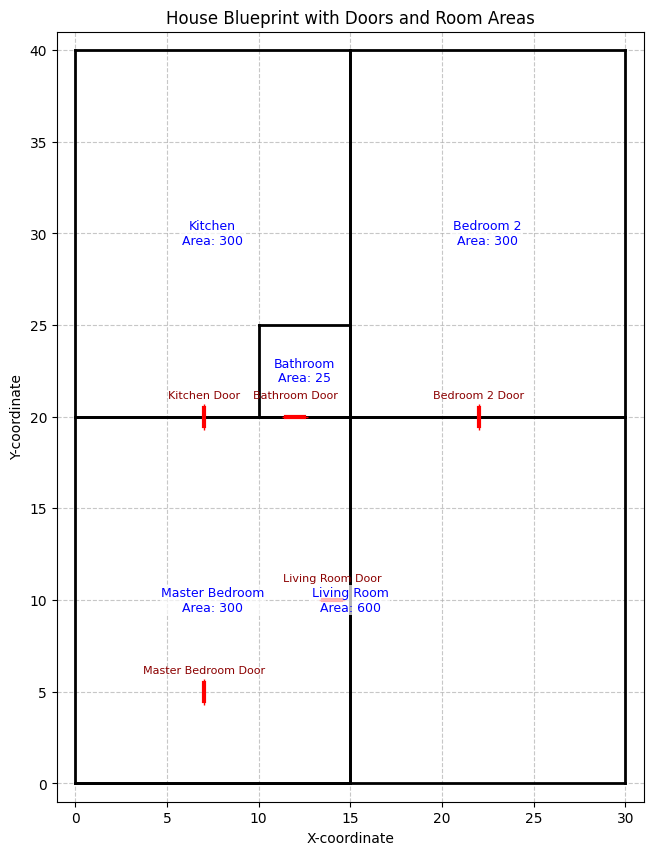

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# Draw walls
for room in house_layout['rooms']:
    for wall in room['walls']:
        x_coords = [wall['start'][0], wall['end'][0]]
        y_coords = [wall['start'][1], wall['end'][1]]
        plt.plot(x_coords, y_coords, color='black', linewidth=2)

# Draw doors
for door in house_layout['doors']:
    x_loc, y_loc = door['location']
    direction = door['direction']

    # Approximate door opening based on direction
    if direction == 'N': # Door opens North (vertical)
        plt.plot([x_loc - 0.5, x_loc + 0.5], [y_loc, y_loc], color='red', linewidth=3, marker='_')
    elif direction == 'S': # Door opens South (vertical)
        plt.plot([x_loc - 0.5, x_loc + 0.5], [y_loc, y_loc], color='red', linewidth=3, marker='_')
    elif direction == 'E': # Door opens East (horizontal)
        plt.plot([x_loc, x_loc], [y_loc - 0.5, y_loc + 0.5], color='red', linewidth=3, marker='|')
    elif direction == 'W': # Door opens West (horizontal)
        plt.plot([x_loc, x_loc], [y_loc - 0.5, y_loc + 0.5], color='red', linewidth=3, marker='|')

    # Optionally add door labels
    plt.text(x_loc, y_loc + 1, door['room'] + ' Door', fontsize=8, ha='center', color='darkred')

# Add room area labels
for room in house_layout['rooms']:
    room_name = room['name']
    area = room_areas.get(room_name, 'N/A')

    # Calculate centroid for text placement
    all_x_coords = []
    all_y_coords = []
    for wall in room['walls']:
        all_x_coords.append(wall['start'][0])
        all_x_coords.append(wall['end'][0])
        all_y_coords.append(wall['start'][1])
        all_y_coords.append(wall['end'][1])

    if all_x_coords and all_y_coords:
        center_x = (min(all_x_coords) + max(all_x_coords)) / 2
        center_y = (min(all_y_coords) + max(all_y_coords)) / 2

        plt.text(center_x, center_y, f"{room_name}\nArea: {area}",
                 fontsize=9, ha='center', va='center', color='blue',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Set plot limits based on house dimensions
house_width = house_layout['house_dimensions']['width']
house_height = house_layout['house_dimensions']['height']
plt.xlim(-1, house_width + 1)
plt.ylim(-1, house_height + 1)

plt.gca().set_aspect('equal', adjustable='box')
plt.title('House Blueprint with Doors and Room Areas')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [1]:
import json

house_layout = {
    "house_dimensions": {"width": 30, "height": 40},
    "rooms": [
        {
            "name": "Living Room",
            "walls": [
                {"type": "exterior", "start": [0, 0], "end": [30, 0]},
                {"type": "exterior", "start": [30, 0], "end": [30, 20]},
                {"type": "interior", "start": [15, 20], "end": [30, 20]},
                {"type": "interior", "start": [15, 0], "end": [15, 20]}
            ]
        },
        {
            "name": "Kitchen",
            "walls": [
                {"type": "exterior", "start": [0, 20], "end": [0, 40]},
                {"type": "exterior", "start": [0, 40], "end": [15, 40]},
                {"type": "interior", "start": [15, 20], "end": [15, 40]},
                {"type": "interior", "start": [0, 20], "end": [15, 20]}
            ]
        },
        {
            "name": "Master Bedroom",
            "walls": [
                {"type": "exterior", "start": [15, 0], "end": [0, 0]},
                {"type": "exterior", "start": [0, 0], "end": [0, 20]},
                {"type": "interior", "start": [0, 20], "end": [15, 20]},
                {"type": "interior", "start": [15, 0], "end": [15, 20]}
            ]
        },
        {
            "name": "Bedroom 2",
            "walls": [
                {"type": "exterior", "start": [15, 20], "end": [15, 40]},
                {"type": "exterior", "start": [15, 40], "end": [30, 40]},
                {"type": "exterior", "start": [30, 40], "end": [30, 20]},
                {"type": "interior", "start": [15, 20], "end": [30, 20]}
            ]
        },
        {
            "name": "Bathroom",
            "walls": [
                {"type": "interior", "start": [10, 20], "end": [10, 25]},
                {"type": "interior", "start": [10, 25], "end": [15, 25]},
                {"type": "interior", "start": [15, 25], "end": [15, 20]},
                {"type": "interior", "start": [10, 20], "end": [15, 20]}
            ]
        }
    ],
    "doors": [
        {"room": "Living Room", "location": [14, 10], "direction": "N"},
        {"room": "Kitchen", "location": [7, 20], "direction": "E"},
        {"room": "Master Bedroom", "location": [7, 5], "direction": "E"},
        {"room": "Bedroom 2", "location": [22, 20], "direction": "W"},
        {"room": "Bathroom", "location": [12, 20], "direction": "N"}
    ]
}

json_layout = json.dumps(house_layout, indent=2)
print(json_layout)


{
  "house_dimensions": {
    "width": 30,
    "height": 40
  },
  "rooms": [
    {
      "name": "Living Room",
      "walls": [
        {
          "type": "exterior",
          "start": [
            0,
            0
          ],
          "end": [
            30,
            0
          ]
        },
        {
          "type": "exterior",
          "start": [
            30,
            0
          ],
          "end": [
            30,
            20
          ]
        },
        {
          "type": "interior",
          "start": [
            15,
            20
          ],
          "end": [
            30,
            20
          ]
        },
        {
          "type": "interior",
          "start": [
            15,
            0
          ],
          "end": [
            15,
            20
          ]
        }
      ]
    },
    {
      "name": "Kitchen",
      "walls": [
        {
          "type": "exterior",
          "start": [
            0,
            20
          